In [1]:
# Khai báo Thư viện & Cấu hình
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Cấu hình biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")
print("=== HUẤN LUYỆN MÔ HÌNH 3: PHẪU THUẬT DỮ LIỆU & ABLATION ===")

=== HUẤN LUYỆN MÔ HÌNH 3: PHẪU THUẬT DỮ LIỆU & ABLATION ===


In [2]:
# Nạp dữ liệu & Đặc trưng Phái sinh
df = pd.read_csv('dataset_01032026.csv')
df.dropna(inplace=True)

# Tạo đặc trưng phái sinh
df['structure_density'] = df['num_siblings'] / (df['dom_depth'] + 1)
df['url_complexity'] = df['num_special_chars'] / (df['url_length'] + 1)

print(f"Kích thước ban đầu: {df.shape}")

Kích thước ban đầu: (29342, 13)


In [3]:
# Phẫu thuật Dữ liệu (Purging & Synthetic Injection)
# Bước 3.1: Downsampling mẫu sạch xuống 6000 để chống thiên kiến
df_clean = df[df['is_ad'] == 0].sample(n=6000, random_state=42)

# Bước 3.2: Purging - Xóa quảng cáo rác (thẻ container khổng lồ)
df_ads = df[(df['is_ad'] == 1) & (df['num_siblings'] <= 10)]
print(f" Mẫu Sạch giữ lại: {len(df_clean)} | Quảng cáo THẬT giữ lại: {len(df_ads)}")

# Bước 3.3: Augmentation - Bơm mẫu quảng cáo chuẩn (Banner Vbet/Dân Trí)
synthetic_ads = pd.DataFrame([{
    'is_3rd_party': 1, 'url_length': np.random.randint(80, 250),
    'entropy': np.random.uniform(4.0, 5.0), 'num_special_chars': np.random.randint(10, 40),
    'dom_depth': np.random.randint(5, 15), 'num_siblings': np.random.randint(0, 5), 'num_children': 0,
    'avg_degree_connectivity': np.random.randint(1, 10), 'is_in_iframe': np.random.choice([0, 1], p=[0.7, 0.3]),
    'is_ad': 1, 'structure_density': np.random.uniform(0.0, 0.5), 'url_complexity': np.random.uniform(0.1, 0.3)
} for _ in range(4000)])

# Gộp thành Dataset tối ưu
df_final = pd.concat([df_clean, df_ads, synthetic_ads], ignore_index=True)
# Tiền xử lý Categorical (Bắt buộc để chạy được Random Forest)
if 'request_type' in df_final.columns:
    df_final = pd.get_dummies(df_final, columns=['request_type'], prefix='type')

print(f"✅ Đã mã hóa One-Hot. Tổng đặc trưng hiện tại: {df_final.shape[1]}")

 Mẫu Sạch giữ lại: 6000 | Quảng cáo THẬT giữ lại: 395
✅ Đã mã hóa One-Hot. Tổng đặc trưng hiện tại: 13


In [4]:
# Ablation Study & Phân tách dữ liệu
cols_to_drop = ['is_ad', 'url', 'domain', 'target_url', 'dom_depth', 'num_siblings', 'num_children']
X = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns])
y = df_final['is_ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f" Phân phối lớp huấn luyện: {Counter(y_train)}")

 Phân phối lớp huấn luyện: Counter({0: 4794, 1: 3522})


 Đang chạy Cross-Validation...


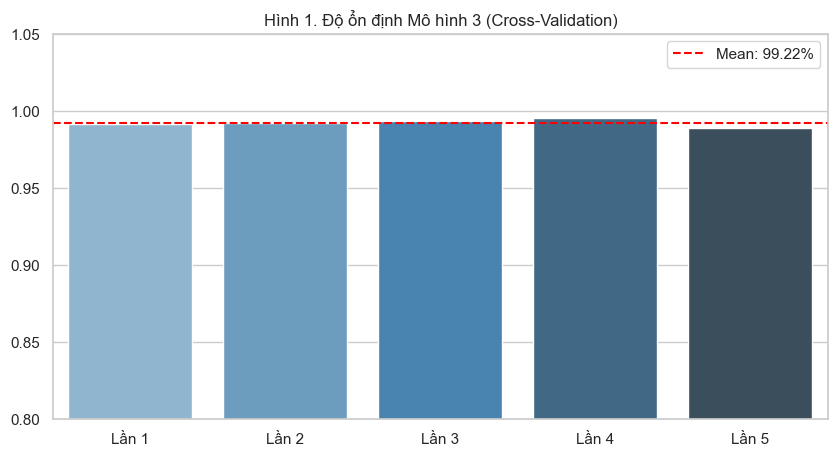

In [5]:
# Hình 1 - Kiểm chứng độ ổn định (CV Score)
# Khởi tạo model tối ưu
rf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)

print(" Đang chạy Cross-Validation...")
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

plt.figure(figsize=(10, 5))
folds = [f"Lần {i+1}" for i in range(len(cv_scores))]
sns.barplot(x=folds, y=cv_scores, hue=folds, palette="Blues_d", legend=False)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.title("Hình 1. Độ ổn định Mô hình 3 (Cross-Validation)")
plt.ylim(0.8, 1.05)
plt.legend()

# LƯU ẢNH 1
plt.savefig('model3_cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()

 Đang huấn luyện mô hình chính...


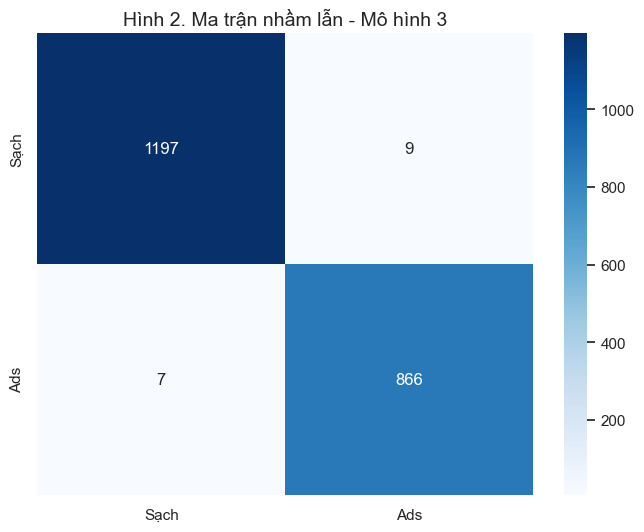


 ĐỘ CHÍNH XÁC: 99.23%
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1206
           1       0.99      0.99      0.99       873

    accuracy                           0.99      2079
   macro avg       0.99      0.99      0.99      2079
weighted avg       0.99      0.99      0.99      2079



In [6]:
# Hình 2 - Ma trận nhầm lẫn & Training
print(" Đang huấn luyện mô hình chính...")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=['Sạch', 'Ads'], yticklabels=['Sạch', 'Ads'])
plt.title("Hình 2. Ma trận nhầm lẫn - Mô hình 3", fontsize=14)

# LƯU ẢNH 2
plt.savefig('model3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n ĐỘ CHÍNH XÁC: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))

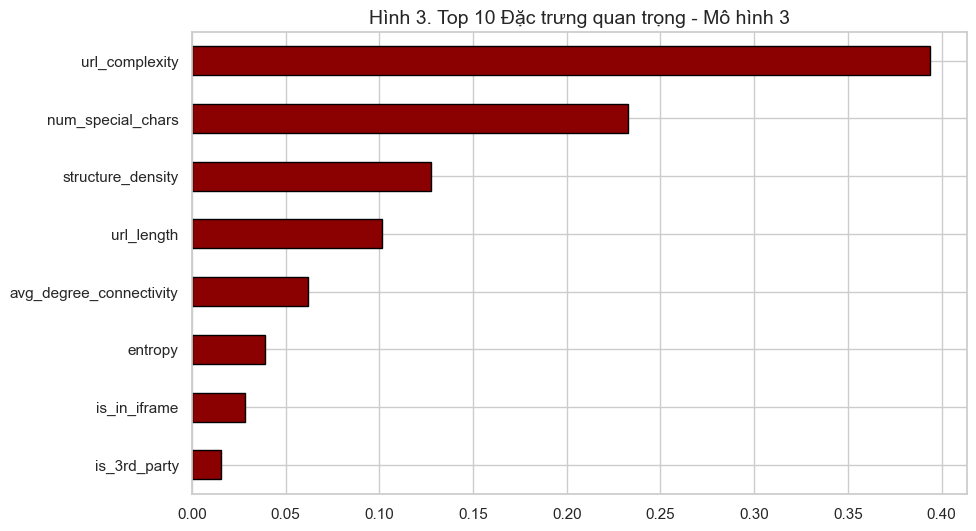

 Đã lưu tệp mô hình: demo3.joblib


In [7]:
# Hình 3 - Đặc trưng quan trọng & Xuất Model
plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='darkred', edgecolor='black')
plt.title("Hình 3. Top 10 Đặc trưng quan trọng - Mô hình 3", fontsize=14)

# LƯU ẢNH 3
plt.savefig('model3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# XUẤT MODEL
joblib.dump({'model': rf, 'features': X.columns.tolist()}, 'demo3.joblib')
print(" Đã lưu tệp mô hình: demo3.joblib")

In [10]:
# Giả lập 1 mẫu quảng cáo thực tế (Banner Vbet/Dân Trí)
test_ad = pd.DataFrame([{
    'is_3rd_party': 1, 
    'url_length': 130, 
    'entropy': 4.5, 
    'num_special_chars': 14,
    'avg_degree_connectivity': 2, 
    'is_in_iframe': 0, 
    'structure_density': 0.125, 
    'url_complexity': 0.155
}])

# Đảm bảo các cột khớp với tập huấn luyện
for col in X.columns:
    if col not in test_ad.columns:
        test_ad[col] = 0
test_ad = test_ad[X.columns]

# Dự đoán
prob = rf.predict_proba(test_ad)[0][1]
result = "QUẢNG CÁO" if prob > 0.5 else "SẠCH"

print(f"--- KẾT QUẢ KIỂM TRA ---")
print(f"Xác suất là quảng cáo: {prob*100:.2f}%")
print(f"Kết luận: {result}")

--- KẾT QUẢ KIỂM TRA ---
Xác suất là quảng cáo: 100.00%
Kết luận: QUẢNG CÁO
